In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


In [3]:
X, y = datasets.make_blobs(n_samples=100, random_state=4, centers=2, cluster_std=2)
X[:5], y[:5]
# в X хранятся координаты точек ( например (13, 1) )
# в y хранятся принадлежность точки к классу ( В нашем случае 0 или 1 )


(array([[13.78731721,  1.73323541],
        [10.68075246,  3.87600675],
        [ 8.09139034,  0.36429043],
        [10.80129018,  6.34922981],
        [ 8.78819007,  2.53766878]]),
 array([0, 1, 1, 1, 0]))

In [4]:
# Данная функция задает цвет точек ( В нашем случае если класс точки=0, то она голубая, в противном случае зеленая)
def get_class_color(class_label):
    return 'green' if class_label else 'blue'

In [5]:
# X - точки, y - классы точек
# new_points=None - Новые неизвестные точки — для которых угадываем цвет ( в нашем случае их не будет )
# new_prediction=None - Угаданынй цвет для новых точек ( результат алгоритма ) , ( в нашем случае их не будет ) 
# nearest_points=None - Ближайщие соседи точки, которые помогли угадать цвет ( В нашем случае их не будет )
# file_name=None - Название файла чтобы сохранить график ( В нашем случае его не будет )
def plot_points(X, y, new_points=None, new_prediction=None, nearest_points=None, file_name=None):
    plt.figure(figsize=(8,8)) # Создает квадратный график 800x800 or 8x8 дюймов
    
    plt.scatter(X[:,0], X[:,1], c=[get_class_color(y_i) for y_i in y], s=100, edgecolor='black', alpha=0.3)
    # X[:,0] - все координаты точек по оси X ||| X[:,1] - все координаты точек по оси Y ||| c=[get_class_color(y_i) for y_i in y] - определение цвета
    # s=100 - размер точки ( в нашем случае 100px ) ||| edgecolor='black' - цвет рамки ||| alpha=0.3 - прозрачность точки ( в нашем случае 30% )  

    # Если есть нвоые точки то рисуем их черными
    if new_points is not None:
        plt.scatter(new_points[:,0], new_points[:,1], c='black', s=100, edgecolor='black')

    # Перекрашивает новые точки с черного на предсказанный цвет
    if new_prediction is not None:
        plt.scatter(new_points[:,0], new_points[:,1], c=[get_class_color(i) for i in new_prediction], s=100, edgecolor='black')

    # Подсвечивает красным ближайщих соседей точки (для kNN)
    if nearest_points is not None:
        plt.scatter(nearest_points[:,0], nearest_points[:,1], c='red', s=100, edgecolor='black')

    plt.title("Задача классификации. Какой цвет будет у новой пары (x1, x2)?") # заголовок графика над всем рисунком
    plt.xlabel("x1 (функция)") # заголовок оси x
    plt.ylabel("x2 (функция)") # заголовок оси y

    # Если был передан параметр file_name, то сохраняем его в файл
    if file_name:
        plt.savefig(filename) 

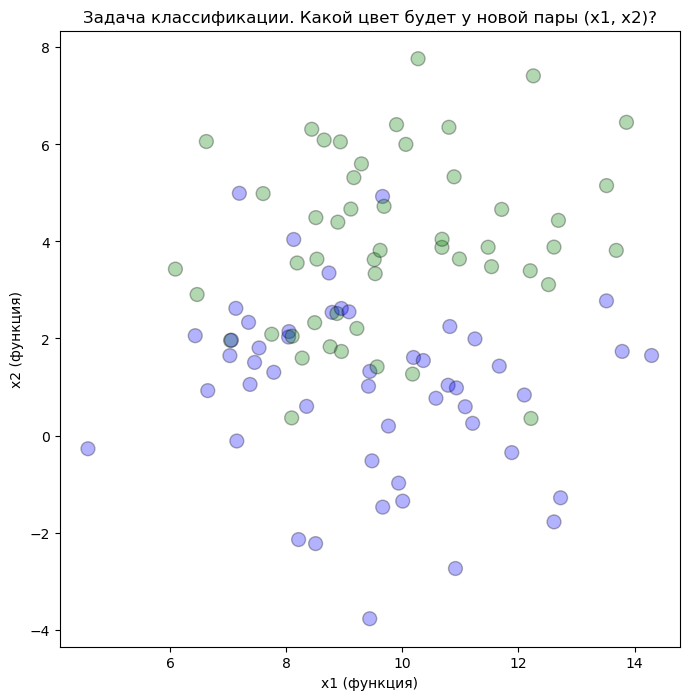

In [6]:
plot_points(X, y)

In [7]:
X_new = np.array([[12,6]])

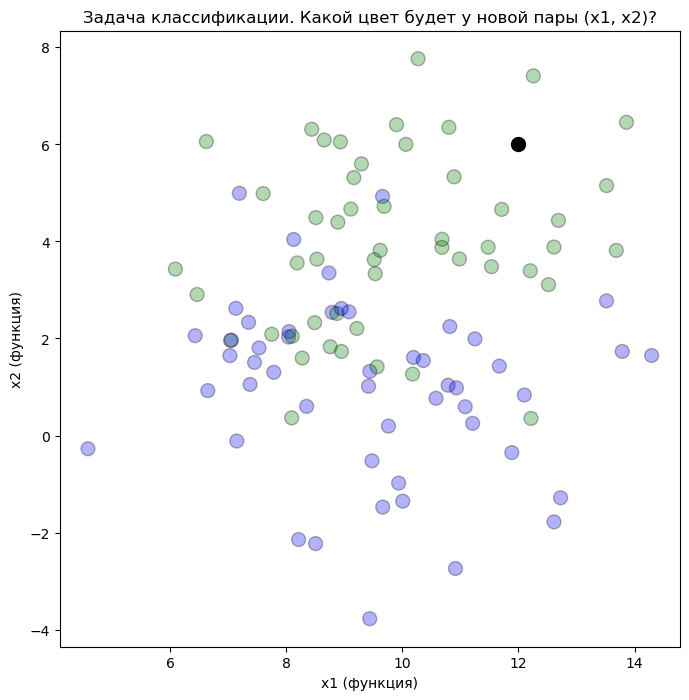

In [8]:
plot_points(X,y, new_points=X_new)

In [9]:
X_new = np.array([[12, 6]]) # Создание новой тестовой точки с координатами вида:
#     [
#       [12,6]
#     ]
X_new 

array([[12,  6]])

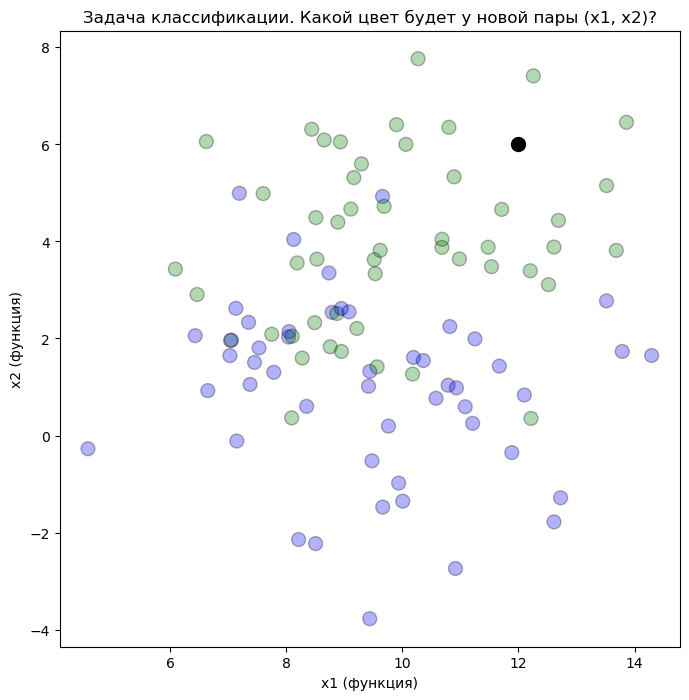

In [10]:
plot_points(X, y, new_points=X_new) # График с новой тестовой точкой


In [11]:
from scipy.spatial.distance import euclidean # Импорт функции евклидового расстояния

# Функция находит индекс ближайщей точки из X к новой точке x_new.
def find_nearest_point_index(x_new, X):
    d_min = euclidean(x_new, X[0]) # инициализирует минимальное расстояние расстоянием до первой точки.
    min_idx = 0 # индекс первой точки
    for idx in range(1,X.shape[0]): # цикл который проходит по всем точкам.
        d = euclidean(x_new, X[idx]) # расстояние от текущей точки до x_new
        if d < d_min: # если текущая точка меньше изначально заданной
            d_min = d # теперь минимальная точка=текущей
            min_idx = idx # индекс минимальной точки теперь равен текущему

    return min_idx # возвращаем индекс минимальной точки
    

min_idx = find_nearest_point_index(X_new[0], X) # находим индекс ближайщей точки через нашу функцию

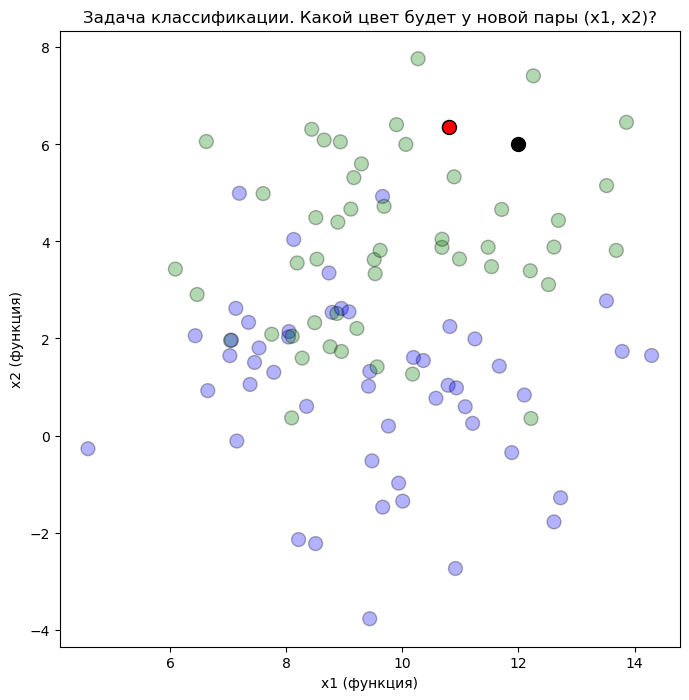

In [12]:
plot_points(X, y, new_points=X_new, nearest_points=X[[min_idx]])  # Рисует крафик с ближайщей точкой

In [13]:
# Функция предсказания пренадлежности точки к какому то классу
def predict_class(x_new, X, y):
    min_idx = find_nearest_point_index(x_new[0], X) # Находит ближайщего соседа
    return y[min_idx] # возвращает класс ближайщего соседа

y_new = predict_class(X_new, X, y) # Делает предсказание класса для новой точки
    

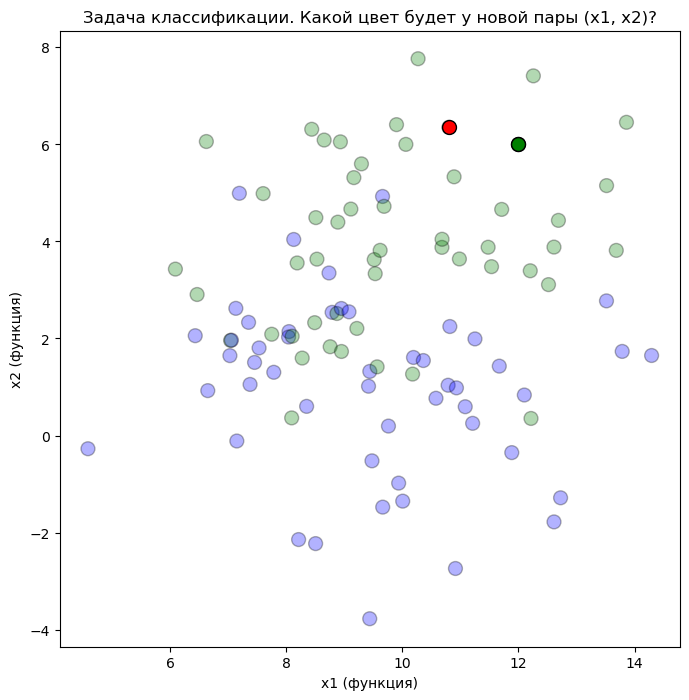

In [14]:
plot_points(X, y, new_points=X_new, new_prediction=[y_new], nearest_points=X[[min_idx]])
# Показывает принадлежность новой точки к определенному классу

In [15]:
X1_new = np.array([[12,-2]]) # создание новой точки
min_idx1 = find_nearest_point_index(X1_new[0], X) # индекс ближайщей точки к нашей 
y_new1 = predict_class(X1_new, X, y) # принадлежность нашей точки к классу

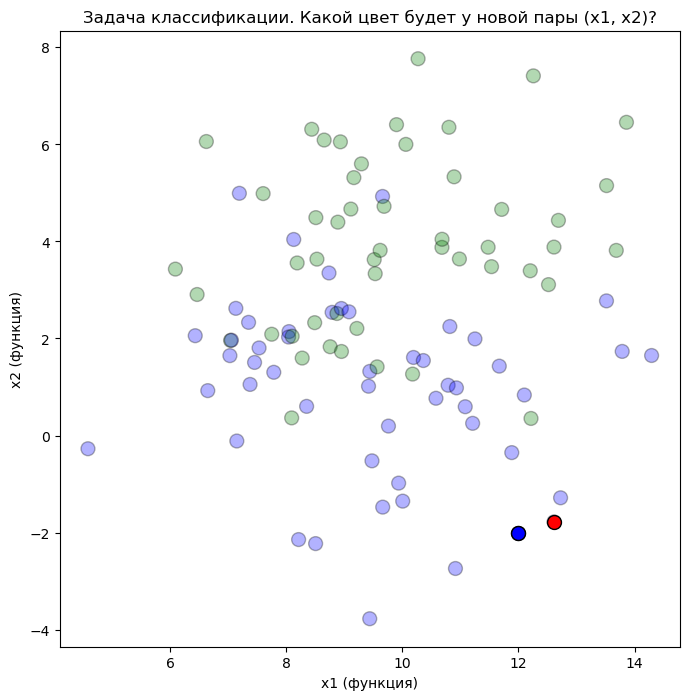

In [16]:
plot_points(X, y, new_points=X1_new, new_prediction=[y_new1], nearest_points=X[[min_idx1]]) # Еще один пример работы всего алгоритма

## Sklearn

In [17]:
from sklearn.neighbors import KNeighborsClassifier # Иморт готового класса kNN

knn = KNeighborsClassifier(n_neighbors=1) # создание объекта kNN классификатора с k=1
knn.fit(X,y) # обучает k-NN модель на данных X и метках y
y_pred = knn.predict(X_new) #  делает предсказание для новой точки X_new=[12,6] с помощью обученной sklearn модели

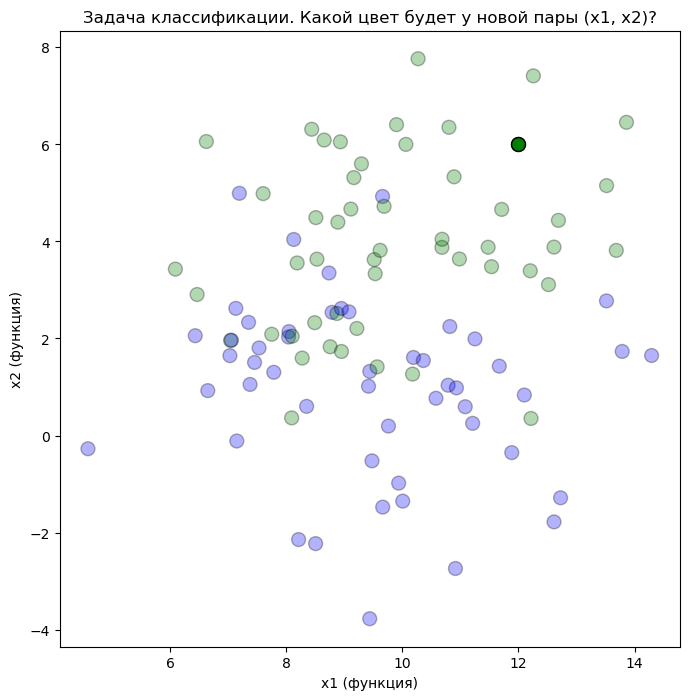

In [18]:
plot_points(X, y, new_points=X_new, new_prediction=[y_pred]) # рисует график на основе обучения 

In [19]:
X_new3 = np.c_[np.random.randint(5,15,10), np.random.randint(-2,8,10)]
# np.c_ - конкатенация массивов numpy
# np.random.randint(нижняя_граница, верхняя_граница, кол-во_чисел) - создает массив из 10 чисел от нижней_границы до верхней_границы

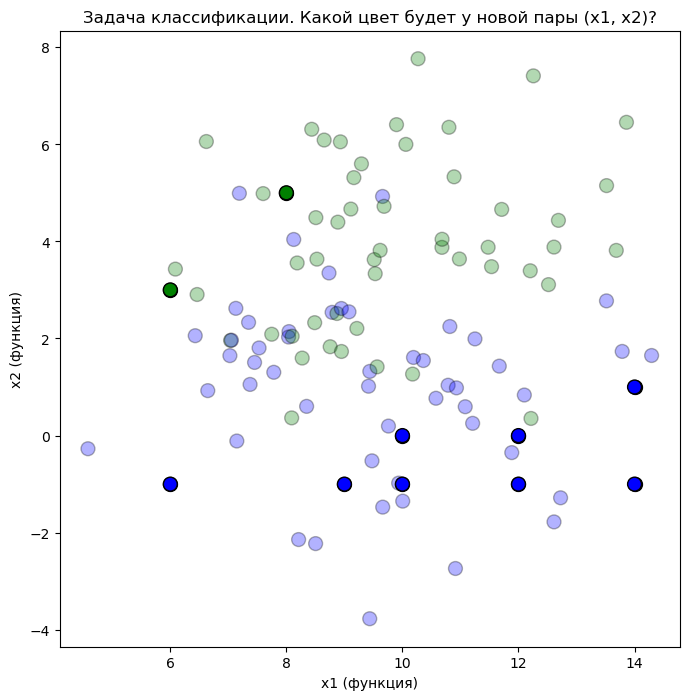

In [20]:
plot_points(X, y, new_points=X_new3, new_prediction=knn.predict(X_new3)) # рисует график на основе новых точек

In [35]:
from scipy.spatial.distance import cdist # импортирует функцию для вычисления матрицы расстояний между двумя наборами точек
from collections import Counter # импортирует класс-счетчик для подсчета частоты элементов

def predict_class(x_new, X, y, k=1): # обновляет функцию для k-NN с любым k
    #  cdist рассчитывает попарные расстояния между объектами
    dist = cdist(x_new, X) #  вычисляет матрицу расстояний от всех новых точек до всех тренировочных

    nearest_y = y[np.argpartition(dist, k, axis=1)[:, :k]] # находит классы k ближайших соседей для каждой новой точки.
    # np.np.argpartition() - argpartition находит отсортированные индексы 

    # Этот код возвращает массив из самых частых значений в каждой строке nearest_y.
    return np.array([Counter(row).most_common(1)[0][0] for row in nearest_y]) 
    # Counter(row) — считает, сколько раз каждый элемент встречается в строке
    # .most_common(1) — берёт самый частый элемент
    # [0][0] — извлекает само значение, а не количество
    # np.array(...) — собирает все такие значения в NumPy-массив.

In [36]:
y_pred = predict_class(X_new3, X, y, k=3) # Это предсказание класса для новых данных X_new по алгоритму k ближайших соседей

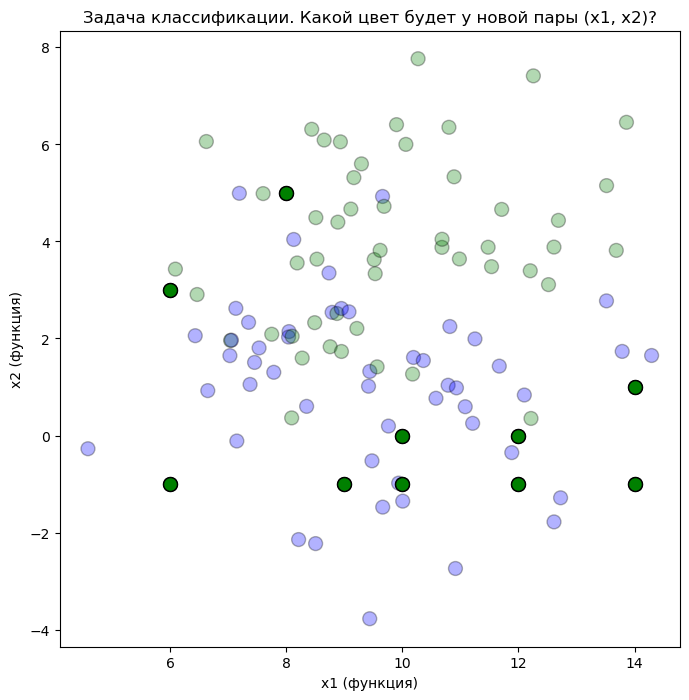

In [22]:
plot_points(X, y, new_points=X_new3, new_prediction=y_pred) # рисует график

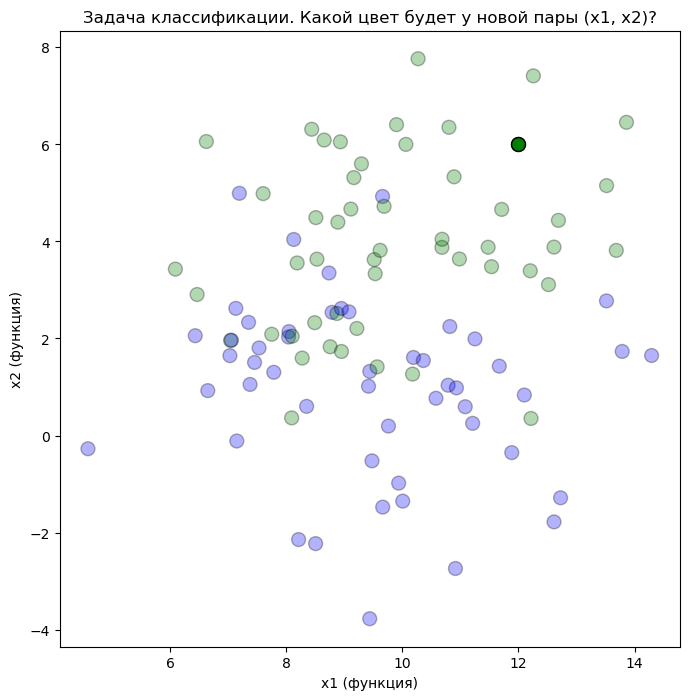

In [23]:
knn = KNeighborsClassifier(n_neighbors=3) #  создаёт модель kNN-классификатора с числом соседей=3
knn.fit(X, y) # обучает модель на данных X и метках y
y_pred = knn.predict(X_new) # получает предсказанные классы для новых данных X_new с помощью уже обученной модели knn
plot_points(X, y, new_points=X_new, new_prediction=y_pred) # строит новый график

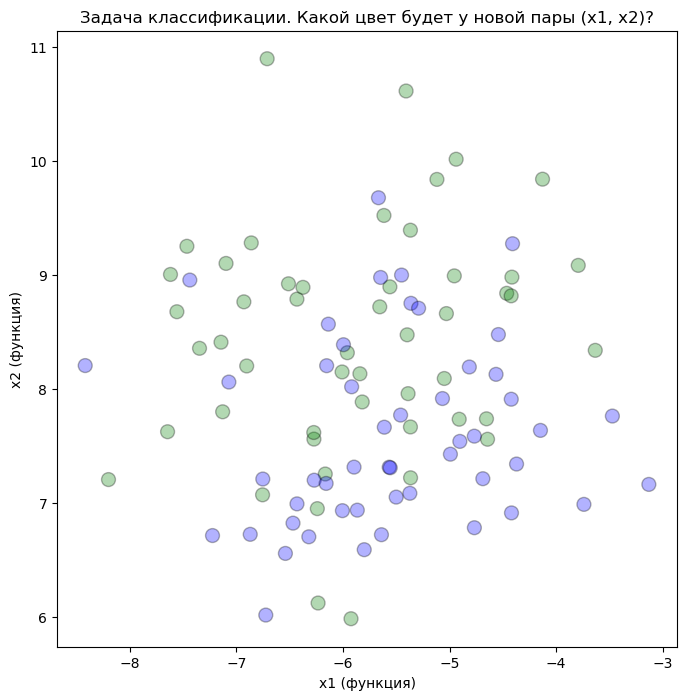

In [39]:
X, y = datasets.make_blobs(n_samples=100, random_state=5, centers=2) # генерирует синтетический набор данных для задач машинного обучения
# make_blobs() - Функция создаёт n случайных точек ( В нашем случае n_samples=100, значит будет создано 100 случайных точек) разделенных на k кластеров
# ( в нашем случае сenters=2, значит 2 кластера)
plot_points(X, y) # рисует график с новыми точками

# Влияние числа соседей k

In [52]:
h = .02 # шаг сетки для плавного графика
# Находим границы данных + отступ 0.5 для красивого графика
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) # создаёт регулярную 2D-сетку координат для визуализации или вычислений
# np.meshgrid() - Принимает два 1D-массива (для осей X и Y) и возвращает две 2D-матрицы xx, yy одинаковой формы.
x_pred = np.c_[xx.ravel(), yy.ravel()] # преобразует 2D-сетку координат в плоский массив точек для предсказания модели.
# xx.ravel(), yy.ravel() -  "сплющивают" 2D-матрицы xx, yy в 1D-массивы (столбцы).

In [53]:
# Функция создает и обучает классификатор kNN, затем визуализирует его гранницу решений в виде цветной сетки на 2D-графике
def plot_knn_classifier(k):
    knn = KNeighborsClassifier(n_neighbors=k) # Создает экземпляр классификатора knn с числом соседей k
    knn.fit(X, y) # Обучает модель на тренировочных данных X(координаты точек) и метках y (классы класстеров)
    Z = knn.predict(x_pred) # Предсказывает классы точек для x_pred
    Z = Z.reshape(xx.shape) # Преобразует одномерный массив предсказаний обратно в форму 2D-сетки xx.
    plt.figure(1, figsize=(12,8)) # Создает новую фигуру plt размеров 12x8 дюймов
    plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired) # рисует цветную заливку сетки, где цвет пикселя соответствует предсказанному классу Z, используя 
    # цветовую карту Paired

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired) # Рисует scatter plot всех 100 точек из make_blobs
    plt.xlim(xx.min(), xx.max()) # Устанавливает пределы осей точно по границам сетки xx, yy для идеального совпадения цветовой заливки.
    plt.ylim(yy.min(), yy.max()) # Устанавливает пределы осей точно по границам сетки xx, yy для идеального совпадения цветовой заливки.
    plt.xticks(()) # Убирает деления и подписи с осей — чистый график без отвлекающих меток.
    plt.yticks(()) # Убирает деления и подписи с осей — чистый график без отвлекающих меток.
    plt.show() # Показывает готовый график с наложенными точками поверх цветной сетки.

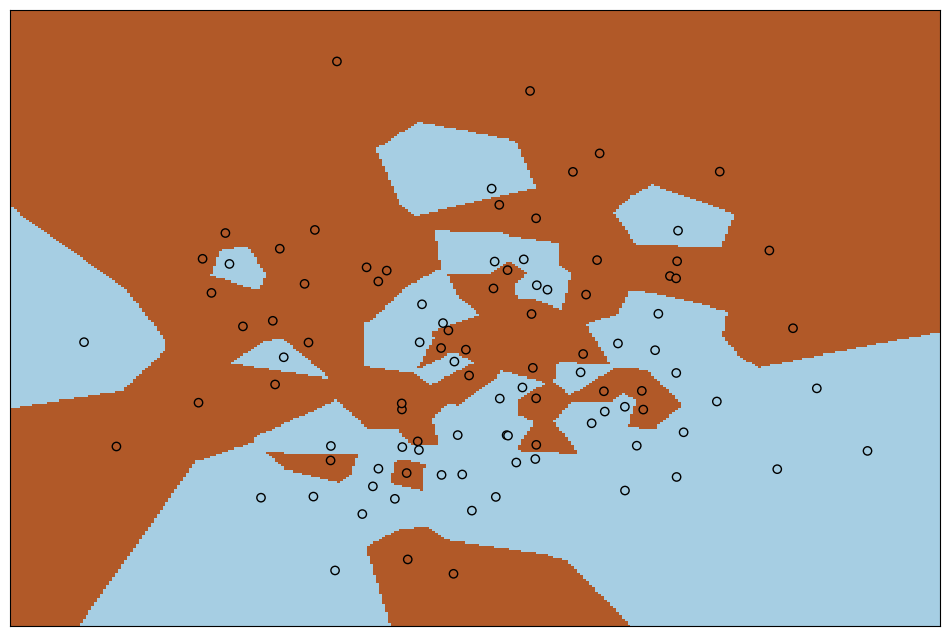

In [58]:
plot_knn_classifier(1) # k=1: сложная граница, переобучение

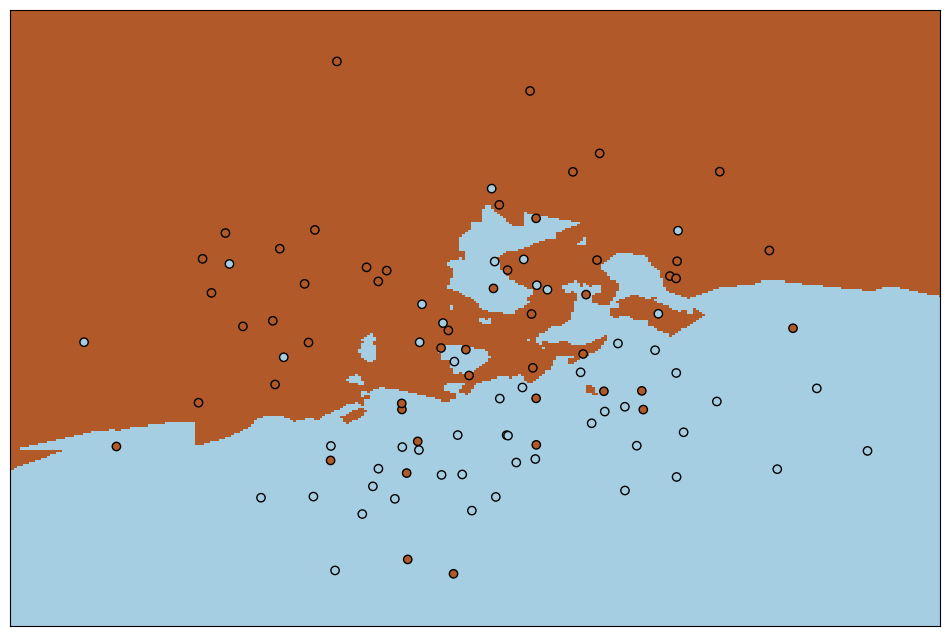

In [59]:
plot_knn_classifier(10) # k=10: баланс сложности и обобщения  

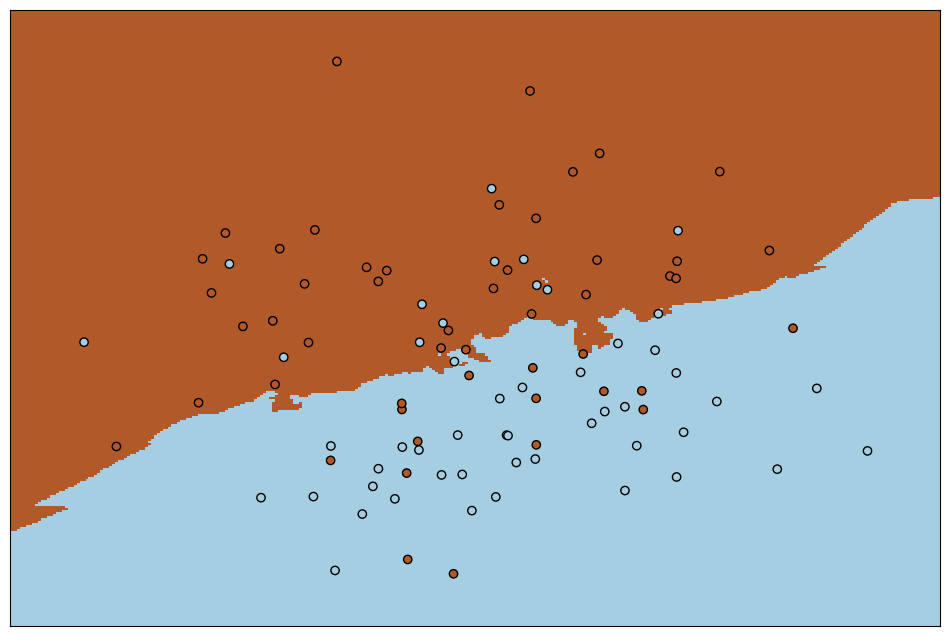

In [60]:
plot_knn_classifier(30) # k=30: гладкая граница, недообучение

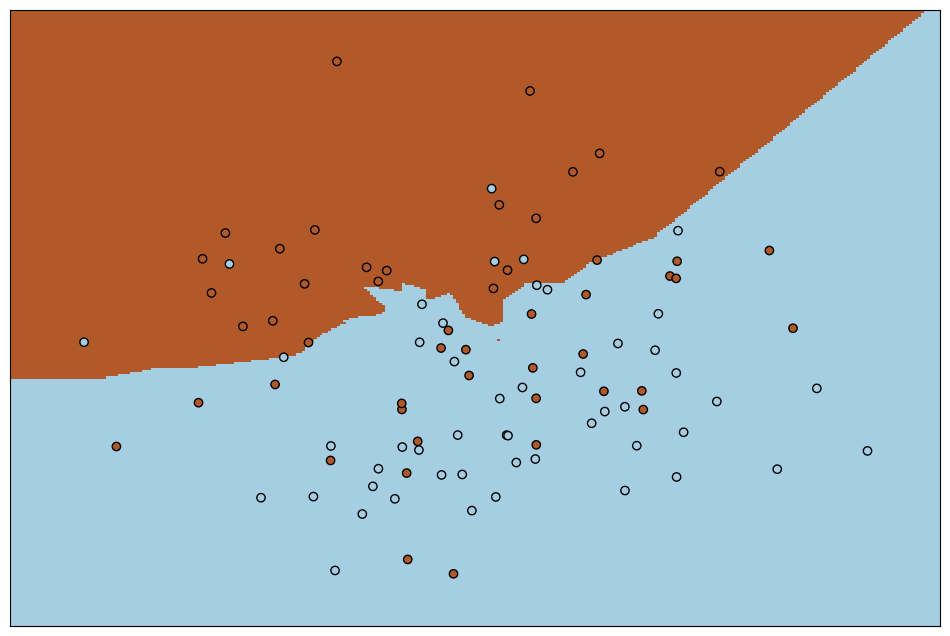

In [63]:
plot_knn_classifier(90) # k=90, Сильное недообучение

# Нормализация данных в kNN

In [65]:
X, y = datasets.make_blobs(n_samples=100, random_state=4, centers=2, cluster_std=2)
X[:, 1] *= 1000000000 #  искусственно ломает данные, делая вторую координату доминирующей
X[:5], y[:5]

(array([[1.37873172e+01, 1.73323541e+09],
        [1.06807525e+01, 3.87600675e+09],
        [8.09139034e+00, 3.64290431e+08],
        [1.08012902e+01, 6.34922981e+09],
        [8.78819007e+00, 2.53766878e+09]]),
 array([0, 1, 1, 1, 0]))

In [68]:
# рисует интерактивную демонстрацию KNN — показывает тренировочные точки и места для новых предсказаний
def plot_points_scaled(X, y, new_points=None, new_prediction=None, nearest_points=None, file_name=None):
    # рисует точки с прозрачностью, чёрной обводкой и размером 100
    plt.scatter(X[:, 0], X[:, 1], c=[get_class_color(y_i) for y_i in y], s=100, edgecolor='black', alpha=0.3) 
    # создаёт или активирует фигуру №1 размером 12x8 дюймов
    plt.figure(1, figsize=(12, 8))
    plt.title("Задача классификации: Какой цвет будет у новой пары (x1, x2)?") # Задает название графику
    plt.xlabel("x1 (Функция)") # Задает название по оси x
    plt.ylabel("x2 (Функция)")
    plt.gca().set_aspect('equal', adjustable='datalim')

    if file_name: # Если в параметрах передается название, то сохраняет в файл по этому имени
        plt.savefig(filename)

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# accuracy_score — точность (доля правильно предсказанных меток из всех).
# precision_score — точность (доля истинно положительных среди предсказанных положительных).
# recall_score — полнота (доля истинно положительных среди всех реальных положительных).
# f1_score — гармоническое среднее precision и recall для баланса метрик.

In [81]:
# считает и выводит стандартные метрики качества для задачи классификации
def quality(prediction_y, true_y):
    accuracy = accuracy_score(prediction_y, true_y) # Доля правильных предсказаний среди всех объектов
    precission = precision_score(prediction_y, true_y) # насколько точны положительные предсказания
    recall = recall_score(prediction_y, true_y) # полнота
    f1 = f1_score(prediction_y, true_y) # гармоническое среднее precision и recall
    print("Доля правильных ответов: {:.3f}\nТочность: {:.3f}\nПолнота: {:.3f}\nF1: {:.3f}".format(
        accuracy, precission, recall, f1
    ))

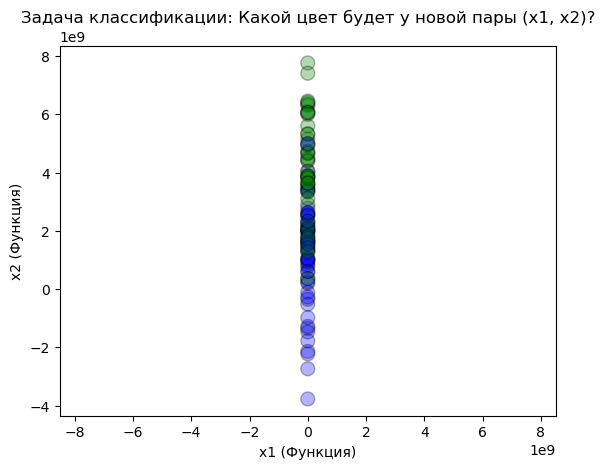

In [82]:
plot_points_scaled(X, y)  # Получаются очень скошенные данные

In [84]:
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier(n_neighbors=5) # создаёт экземпляр классификатора K‑ближайших соседей с k = 5
knn.fit(X, y) # «обучает» модель, то есть запоминает обучающие признаки X и соответствующие метки классов y
y_pred = knn.predict(X) # по тем же данным X модель делает предсказания: для каждого объекта находит его 5 
# ближайших соседей в обучающем наборе и ставит тот класс, который чаще всего встречается среди них
quality(y_pred, y)

Доля правильных ответов: 0.810
Точность: 0.760
Полнота: 0.844
F1: 0.800


In [89]:
from sklearn.preprocessing import MinMaxScaler # импортирует класс MinMaxScaler из scikit‑learn, который нужен для масштабирования признаков
# MinMaxScaler() - приводит все данные к 1 масштабу
X_scaled = MinMaxScaler().fit_transform(X) # создаёт экземпляр MinMaxScaler (по умолчанию с диапазоном [0, 1])
#  обучает его на данных X: запоминает, по каждому признаку, минимальные и максимальные значения,

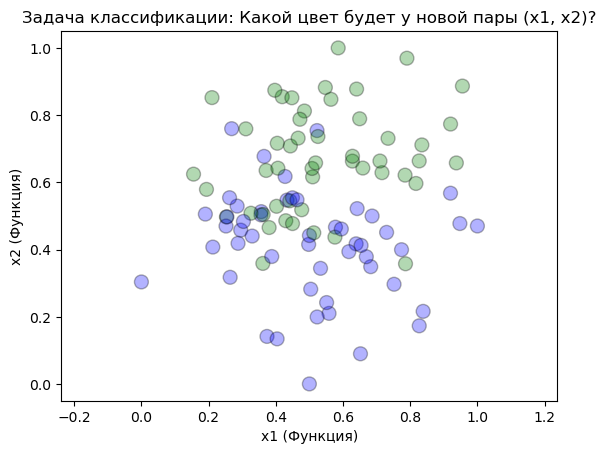

In [90]:
plot_points_scaled(X_scaled, y) # график уже с нормализированными данными

In [92]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, y)
y_pred = knn.predict(X_scaled)
quality(y_pred, y)

# Данные стали лучше

Доля правильных ответов: 0.870
Точность: 0.860
Полнота: 0.878
F1: 0.869


# Выбор параметров модели

## Начинаем запутываться

**Testing set** - в самом начале работы откладываем часть данных и не используем их до внедрения модели в боевое окружение. Это наш финальный и самый верный способ проверить качество готовой модели. 

**Training set** - используется для непосредственной тренировки модели, эти данные модель "видит" во время обучения

**Validation set** - этот набор даннных модель "не видит" во время тренировки, но мы его используем для настройки гиперпараметров, то есть проверяем качество обученной модели и если мы им недовольны - меняем параметры модели и повторяем процедуру. Таким образом, модель хоть напрямую с этими данными и не работает, информацию из них мы всё равно многократно используем и она просачивается в модель в виде настроенных параметров. Т.е., качество модели на валидационной выборке может быть завышено. 


В `sklearn.model_selection` есть функция `train_test_split`, которая случайным (или не очень, если мы того хотим) образом делит выборку на две части. Вместо train и validation их чаще всего (на самом деле всегда) называют train и test, подразумевая, при этом, что истинная "тестовая" выборка хранится отдельно и будет использована в будущем после настройки модели.  

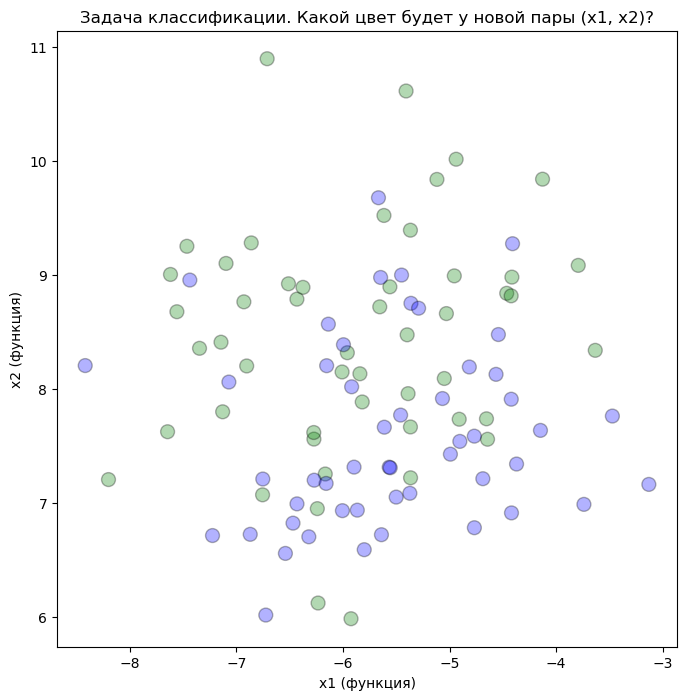

In [93]:
X, y = datasets.make_blobs(n_samples=100, random_state=5, centers=2)
plot_points(X,y)

In [94]:
# подключает из scikit‑learn функцию train_test_split, которая умеет случайно разрезать данные на train и test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
# вызывает эту функцию на двух объектах

In [98]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape
# X_train.shape — сколько объектов и признаков в обучающей выборке
# X_test.shape — сколько объектов и признаков в тестовой выборке
# y_train.shape - размер вектора меток для обучения
# y_test.shape — размер вектора меток для теста

((60, 2), (40, 2), (60,), (40,))

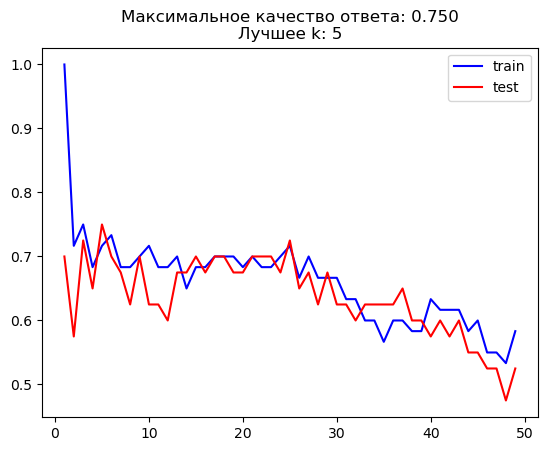

In [100]:
neigbors = range(1,50) # создает диапозон чисел от 1 до 49
accuracy_train = [] # сюда будут добавляться значения accuracy для train
accuracy_test = [] # сюда будут добавляться значения accuracy для test
for k in neigbors:
    knn = KNeighborsClassifier(n_neighbors=k) # создает модель при текущем k
    knn.fit(X_train, y_train) # модель обучается
    accuracy_train.append(accuracy_score(knn.predict(X_train), y_train)) # Считается accuracy на обучщающей выборке
    accuracy_test.append(accuracy_score(knn.predict(X_test), y_test)) # Считается accuracy на тестовой выборке

plt.plot(neigbors, accuracy_train, color='blue', label='train') # рисует линию по оси x(1,49), по оси y - accuracy
plt.plot(neigbors, accuracy_test, color='red', label='test') # аналогично рисует линию accuracy на тестовой выборке
plt.title("Максимальное качество ответа: {:.3f}\nЛучшее k: {}".format(max(accuracy_test), np.argmax(accuracy_test)+1)) # название графика
plt.legend() # отображает пояснение на графике
plt.show() # отображает график в окне

((300, 2), (200, 2), (300,), (200,))

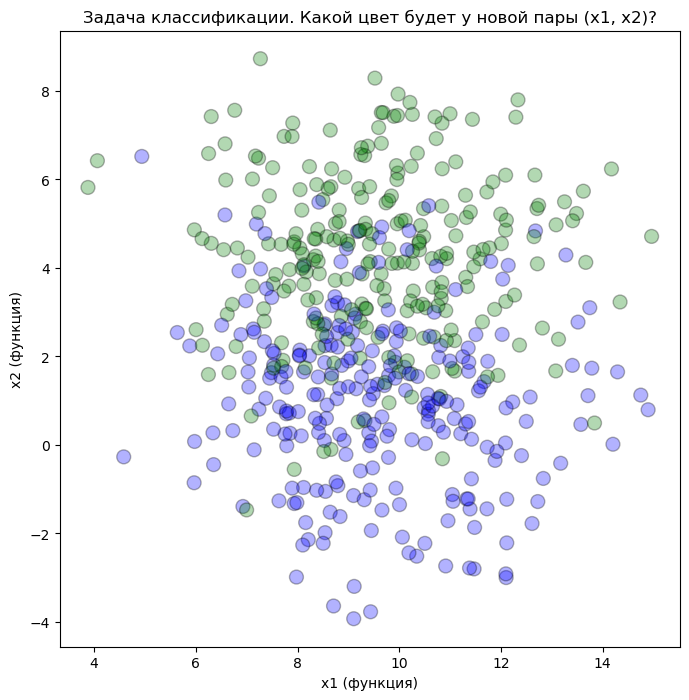

In [105]:
X, y = datasets.make_blobs(n_samples=500, random_state=4, centers=2, cluster_std=2) # Создание исскуственного датасета
# n_samples=500 - создание 500 объектов || random_state=4 - фиксирует случайность чтобы при каждом запуске получались одни и те же данные
# centers=2 - сгененировать 2 кластера (2 облака точек) || cluster_std=2 - задать «разброс» точек вокруг центра каждого кластера
plot_points(X, y) # построение графика

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42) # разделение данных на train и test
X_train.shape, X_test.shape, y_train.shape, y_test.shape # проверка размеров массивов || .shape - показывает размерность массива

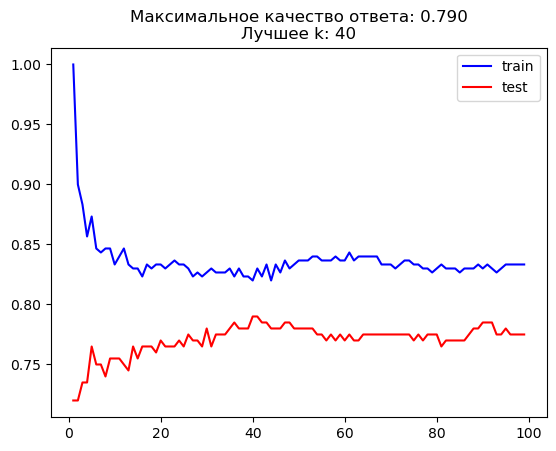

In [108]:
from sklearn.metrics import accuracy_score

neigbors = range(1, 100) # создает диапозон чисел от 1 до 99
accuracy_train = [] # сюда будут добавляться занчения accuracy для train 
accuracy_test = [] # сюда будут добавляться значения accuracy для test
for k in neigbors:
    knn = KNeighborsClassifier(n_neighbors=k) # создаем knn модель с k ближайщих соседей
    knn.fit(X_train, y_train) # обучаем модель на основе тренировочной выборке
    accuracy_train.append(accuracy_score(knn.predict(X_train), y_train)) # Считается и добавляется accuracy на обучщающей выборке
    accuracy_test.append(accuracy_score(knn.predict(X_test), y_test)) # Считается и добавляется accuracy на тестовой выборке

plt.plot(neigbors, accuracy_train, color='blue', label='train') # отрисовка тренировочной выборки
plt.plot(neigbors, accuracy_test, color='red', label='test') # отрисовка тестовой выборки
plt.title("Максимальное качество ответа: {:.3f}\nЛучшее k: {}".format(max(accuracy_test), np.argmax(accuracy_test)+1)) # название графика
plt.legend() # отрисовка обозначений на графике 
plt.show() # отрисовка самого графика

## Кросс-валидация (k-fold cross-validation)

Иногда данных не то чтобы очень много, а потестировать модель всё же хочется, да и получить устойчивые и надежные оценки качества модели - тоже не так плохо. 

Для такого случая была придумана очень полезная техника, использующася повсеместно - кросс-валидация. Наш изначальный датасет мы теперь будем делить не на train-validation-test, а на гораздо большее количество кусочков. В самом начале снова можно отложить тестовую выборку, на которой в самом конце мы проверим качество готовой модели. Далее берем оставшийся тренировочный датасет и делим его на папки (фолды, folds).

Например, задаём число фолдов равным 6 (обычно берется 3 или 5, но на картинке 6 блоков, так что для соответствия будем использовать 6). Теперь мы делим нашу тренировочную выборку на 6 равных кусков. На пяти их них обучаем модель, на шестом - меряем качество. Теперь берем другое сочетание фолдов и снова повторяем обучение/тестирование. Продолжаем, пока каждый из фолдов не поучаствовал в тестировании. Таким образом, мы получаем столько оценок качества, сколько изначально задали фолдов, и столько же раз нам пришлось нашу модель обучать и тестировать. Теперь эти оценки мы можем усреднить, посчитать стандартное отклонение и узнать как, в среднем, ошибается наша модель и какие интервалы у этой ошибки. 

Вычислительно кросс-валидации крайне затратна, но если модель учится быстро, а датасет не сильно большой - это отличный способ получить "честные" оценки качества модели.